<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Synthetic Dataset Generation with LLM Agent and Statistics**


Estimated time needed: **90** minutes


Master the art of creating high-quality synthetic datasets using cutting-edge AI techniques! This hands-on project will teach you to generate realistic, privacy-preserving data for machine learning applications. You'll learn to leverage large language models, implement advanced sampling strategies, and create comprehensive synthetic datasets that maintain statistical properties of real data.

Here's your challenge: You've been hired by "DataHealth," a healthcare analytics company facing a critical problem. The Chief Data Officer explains: "We have incredible machine learning models, but our clients can't share patient data due to HIPAA regulations. We need synthetic datasets that preserve statistical relationships and patterns from real medical data, but contain zero actual patient information. Our data scientists spend weeks manually creating test datasets that still don't capture the complexity of real-world scenarios."

You'll solve this by building a comprehensive synthetic data generation pipeline using modern techniques including LLM-based generation, statistical sampling, GAN-inspired approaches, and validation frameworks - transforming the challenge of data scarcity into an opportunity for privacy-preserving innovation.


### Installing Required Libraries

Installing all libraries may take a while (upto 20 minutes), please be patient. 


In [1]:
%%capture 
%pip install langchain-openai==0.3.30  | tail -n 1
%pip install langchain==0.3.27 | tail -n 1
%pip install langchain-core==0.3.74 | tail -n 1
%pip install openai==1.99.9 | tail -n 1
%pip install pandas==2.3.1 | tail -n 1
%pip install numpy==2.3.2 | tail -n 1
%pip install matplotlib==3.10.5 | tail -n 1
%pip install seaborn==0.13.2 | tail -n 1
%pip install scikit-learn==1.7.1 | tail -n 1
%pip install sdv==1.18.0 | tail -n 1
%pip install scipy==1.15.2 | tail -n 1

### Importing Required Libraries


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import json
from typing import List, Dict, Any, Optional
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from faker import Faker
from sdv.single_table import GaussianCopulaSynthesizer, CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

from langchain_openai import OpenAI, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain.chat_models import init_chat_model

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# API Disclaimer
This lab uses LLMs provided by OpenAI. This environment has been configured to allow LLM use without API keys so you can prompt them for **free (with limitations)**. With that in mind, if you wish to run this notebook **locally outside** of Skills Network's JupyterLab environment, you will have to configure your own API keys. Please note that using your own API keys means that you will incur personal charges.


In [3]:
# Initialize the LLM for Skills Network environment (free usage)
llm = ChatOpenAI(model="gpt-5-mini", temperature=0.7, max_tokens=2000)

In [4]:
# Uncomment the lines below ONLY if running locally with your own API key
# import os
# os.environ["OPENAI_API_KEY"] = "your-api-key-here"
# llm = init_chat_model("gpt-4o-mini", model_provider="openai", streaming=False, temperature=0.7, max_tokens=2000)

In [5]:
class StatisticalSampler:
    """
    Statistical sampling for numerical and categorical data generation.
    """
    def __init__(self, seed: Optional[int] = 42):
        self.rng = np.random.RandomState(seed)
        self.faker = Faker()
        Faker.seed(seed)
    
    def sample_numerical(self, distribution: str, size: int, **params) -> np.ndarray:
        """
        Sample from various numerical distributions.
        
        Args:
            distribution (str): Type of distribution ('normal', 'uniform', 'exponential', 'beta', 'gamma')
            size (int): Number of samples to generate
            **params: Distribution-specific parameters
            
        Returns:
            np.ndarray: Array of sampled values
        """
        if distribution == "normal":
            return self.rng.normal(params.get('mean', 0), params.get('std', 1), size)
        elif distribution == "uniform":
            return self.rng.uniform(params.get('low', 0), params.get('high', 1), size)
        elif distribution == "exponential":
            return self.rng.exponential(params.get('scale', 1), size)
        elif distribution == "beta":
            return self.rng.beta(params.get('a', 2), params.get('b', 5), size)
        elif distribution == "gamma":
            return self.rng.gamma(params.get('shape', 2), params.get('scale', 1), size)
        else:
            raise ValueError(f"Unknown distribution: {distribution}")
    
    def sample_categorical(self, categories: List[str], size: int, 
                          probabilities: Optional[List[float]] = None) -> np.ndarray:
        """
        Sample categorical data with optional probability weights.
        
        Args:
            categories (List[str]): List of category values
            size (int): Number of samples
            probabilities (Optional[List[float]]): Probability for each category
            
        Returns:
            np.ndarray: Array of sampled categories
        """
        if probabilities is not None:
            probabilities = np.array(probabilities) / np.sum(probabilities)
        return self.rng.choice(categories, size=size, p=probabilities)
    
    def sample_correlated(self, mean: np.ndarray, cov: np.ndarray, size: int) -> np.ndarray:
        """
        Sample from multivariate normal distribution to create correlated features.
        
        Args:
            mean (np.ndarray): Mean vector for each variable
            cov (np.ndarray): Covariance matrix
            size (int): Number of samples
            
        Returns:
            np.ndarray: Array of correlated samples
        """
        return self.rng.multivariate_normal(mean, cov, size)

In [6]:
class LLMDataGenerator:
    """
    LLM-based synthetic data generator for text and structured data.
    """
    def __init__(self, llm):
        self.llm = llm
        self.parser = JsonOutputParser()
    
    def generate_records(self, schema: Dict[str, Any], num_records: int, 
                        context: Optional[str] = None) -> List[Dict[str, Any]]:
        """
        Generate synthetic records following a specified schema.
        
        Args:
            schema (Dict[str, Any]): Field definitions and types
            num_records (int): Number of records to generate
            context (Optional[str]): Additional context for generation
            
        Returns:
            List[Dict[str, Any]]: List of generated synthetic records
        """
        prompt = ChatPromptTemplate.from_messages([
            ("system", "You are an expert at generating realistic synthetic data. "
                      "Generate diverse, realistic records that follow the provided schema. "
                      "Ensure each record is unique and plausible. Return data as a JSON array."),
            ("user", "{input}")
        ])
        
        schema_desc = json.dumps(schema, indent=2)
        context_str = f"\nContext: {context}" if context else ""
        
        input_text = f"""Generate {num_records} synthetic records following this schema:
{schema_desc}{context_str}

Return ONLY a JSON array of records, no additional text."""
        
        chain = prompt | self.llm | self.parser
        
        try:
            result = chain.invoke({"input": input_text})
            return result if isinstance(result, list) else [result]
        except Exception as e:
            print(f"Error generating records: {e}")
            return []
    
    def generate_text_field(self, field_description: str, num_samples: int) -> List[str]:
        """
        Generate synthetic text for a specific field.
        
        Args:
            field_description (str): Description of what to generate
            num_samples (int): Number of samples
            
        Returns:
            List[str]: List of generated text samples
        """
        prompt = ChatPromptTemplate.from_messages([
            ("system", "Generate realistic, diverse text samples. Return as a JSON array of strings."),
            ("user", "Generate {num} examples of: {description}")
        ])
        
        chain = prompt | self.llm | self.parser
        
        try:
            result = chain.invoke({"num": num_samples, "description": field_description})
            return result if isinstance(result, list) else []
        except Exception as e:
            print(f"Error generating text: {e}")
            return []

In [7]:
class ConditionalGenerator:
    """
    Generate synthetic data with conditional dependencies.
    """
    def __init__(self, llm):
        self.llm = llm
        self.parser = JsonOutputParser()
    
    def generate_conditional(self, base_record: Dict[str, Any], 
                           target_field: str, conditions: Dict[str, Any]) -> Any:
        """
        Generate a field value conditioned on other fields.
        
        Args:
            base_record (Dict[str, Any]): Existing record fields
            target_field (str): Field to generate
            conditions (Dict[str, Any]): Conditional constraints
            
        Returns:
            Any: Generated field value
        """
        prompt = ChatPromptTemplate.from_messages([
            ("system", "Generate realistic field values that are consistent with given conditions."),
            ("user", """Given this record: {record}
            
Generate a realistic value for the field '{field}' that satisfies these conditions:
{conditions}

Return only the value, properly formatted for the field type.""")
        ])
        
        chain = prompt | self.llm | StrOutputParser()
        
        try:
            result = chain.invoke({
                "record": json.dumps(base_record),
                "field": target_field,
                "conditions": json.dumps(conditions)
            })
            return result.strip()
        except Exception as e:
            print(f"Error in conditional generation: {e}")
            return None

In [8]:
class DataValidator:
    """
    Validate synthetic data quality and privacy preservation.
    """
    @staticmethod
    def validate_statistical_similarity(real_data: pd.DataFrame, 
                                       synthetic_data: pd.DataFrame) -> Dict[str, Any]:
        """
        Validate that synthetic data has similar statistical properties to real data.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Generated synthetic dataset
            
        Returns:
            Dict[str, Any]: Validation metrics and results
        """
        results = {}
        
        # Compare numerical columns
        numerical_cols = real_data.select_dtypes(include=[np.number]).columns
        
        for col in numerical_cols:
            # Kolmogorov-Smirnov test for distribution similarity
            ks_stat, p_value = stats.ks_2samp(real_data[col], synthetic_data[col])
            
            results[col] = {
                'ks_statistic': ks_stat,
                'p_value': p_value,
                'similar': p_value > 0.05,  # Not significantly different
                'real_mean': real_data[col].mean(),
                'synthetic_mean': synthetic_data[col].mean(),
                'real_std': real_data[col].std(),
                'synthetic_std': synthetic_data[col].std()
            }
        
        return results
    
    @staticmethod
    def check_privacy(real_data: pd.DataFrame, 
                     synthetic_data: pd.DataFrame) -> Dict[str, Any]:
        """
        Check privacy preservation - ensure synthetic records are not too similar to real ones.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset
            
        Returns:
            Dict[str, Any]: Privacy metrics
        """
        # Normalize numerical columns
        numerical_cols = real_data.select_dtypes(include=[np.number]).columns
        
        if len(numerical_cols) == 0:
            return {"status": "No numerical columns to check"}
        
        scaler = StandardScaler()
        real_scaled = scaler.fit_transform(real_data[numerical_cols])
        synthetic_scaled = scaler.transform(synthetic_data[numerical_cols])
        
        # Calculate minimum distance from each synthetic record to any real record
        min_distances = []
        for syn_record in synthetic_scaled[:100]:  # Sample for efficiency
            distances = np.linalg.norm(real_scaled - syn_record, axis=1)
            min_distances.append(np.min(distances))
        
        return {
            'mean_min_distance': np.mean(min_distances),
            'std_min_distance': np.std(min_distances),
            'privacy_risk': 'HIGH' if np.mean(min_distances) < 0.1 else 
                           'MEDIUM' if np.mean(min_distances) < 0.5 else 'LOW'
        }
    
    @staticmethod
    def visualize_comparison(real_data: pd.DataFrame, 
                           synthetic_data: pd.DataFrame, 
                           columns: Optional[List[str]] = None):
        """
        Create visualization comparing real and synthetic data distributions.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset
            columns (Optional[List[str]]): Specific columns to visualize
        """
        if columns is None:
            columns = real_data.select_dtypes(include=[np.number]).columns[:4]
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.ravel()
        
        for idx, col in enumerate(columns[:4]):
            if col in real_data.columns and col in synthetic_data.columns:
                axes[idx].hist(real_data[col], alpha=0.5, label='Real', bins=30)
                axes[idx].hist(synthetic_data[col], alpha=0.5, label='Synthetic', bins=30)
                axes[idx].set_xlabel(col)
                axes[idx].set_ylabel('Frequency')
                axes[idx].legend()
                axes[idx].set_title(f'Distribution: {col}')
        
        plt.tight_layout()
        plt.show()

In [9]:
class SyntheticDataPipeline:
    """
    Complete pipeline for synthetic data generation combining multiple methods.
    """
    def __init__(self, llm, seed: int = 42):
        self.statistical_sampler = StatisticalSampler(seed)
        self.llm_generator = LLMDataGenerator(llm)
        self.conditional_generator = ConditionalGenerator(llm)
        self.validator = DataValidator()
        self.faker = Faker()
        Faker.seed(seed)
    
    def generate_dataset(self, schema: Dict[str, Any], num_records: int, 
                        method: str = 'hybrid') -> pd.DataFrame:
        """
        Generate a complete synthetic dataset.
        
        Args:
            schema (Dict[str, Any]): Dataset schema definition
            num_records (int): Number of records to generate
            method (str): Generation method ('statistical', 'llm', 'hybrid')
            
        Returns:
            pd.DataFrame: Generated synthetic dataset
        """
        if method == 'llm':
            records = self.llm_generator.generate_records(schema, num_records)
            return pd.DataFrame(records)
        
        elif method == 'statistical':
            return self._generate_statistical(schema, num_records)
        
        elif method == 'hybrid':
            return self._generate_hybrid(schema, num_records)
        
        else:
            raise ValueError(f"Unknown method: {method}")
    
    def _generate_statistical(self, schema: Dict[str, Any], num_records: int) -> pd.DataFrame:
        """Generate dataset using statistical methods."""
        data = {}
        
        for field, config in schema.items():
            field_type = config.get('type', 'numerical')
            
            if field_type == 'numerical':
                distribution = config.get('distribution', 'normal')
                params = config.get('params', {})
                data[field] = self.statistical_sampler.sample_numerical(
                    distribution, num_records, **params
                )
            
            elif field_type == 'categorical':
                categories = config.get('categories', [])
                probabilities = config.get('probabilities', None)
                data[field] = self.statistical_sampler.sample_categorical(
                    categories, num_records, probabilities
                )
        
        return pd.DataFrame(data)
    
    def _generate_hybrid(self, schema: Dict[str, Any], num_records: int) -> pd.DataFrame:
        """Generate dataset using hybrid approach."""
        # Start with statistical generation for numerical fields
        data = {}
        
        # Generate numerical and simple categorical fields statistically
        for field, config in schema.items():
            field_type = config.get('type', 'numerical')
            
            if field_type == 'numerical':
                distribution = config.get('distribution', 'normal')
                params = config.get('params', {})
                data[field] = self.statistical_sampler.sample_numerical(
                    distribution, num_records, **params
                )
            
            elif field_type == 'categorical' and 'categories' in config:
                categories = config.get('categories', [])
                probabilities = config.get('probabilities', None)
                data[field] = self.statistical_sampler.sample_categorical(
                    categories, num_records, probabilities
                )
        
        df = pd.DataFrame(data)
        
        # Use LLM for text fields and complex categorical
        for field, config in schema.items():
            if config.get('type') == 'text' or (config.get('type') == 'categorical' and 'categories' not in config):
                description = config.get('description', f'Generate {field}')
                text_samples = self.llm_generator.generate_text_field(description, num_records)
                if len(text_samples) == num_records:
                    df[field] = text_samples
        
        return df

In [10]:
# Initialize the pipeline
pipeline = SyntheticDataPipeline(llm)

# Define a healthcare dataset schema
patient_schema = {
    'age': {
        'type': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 55, 'std': 15}
    },
    'blood_pressure_systolic': {
        'type': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 125, 'std': 15}
    },
    'blood_pressure_diastolic': {
        'type': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 80, 'std': 10}
    },
    'bmi': {
        'type': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 26.5, 'std': 4.5}
    },
    'gender': {
        'type': 'categorical',
        'categories': ['Male', 'Female', 'Other'],
        'probabilities': [0.48, 0.48, 0.04]
    },
    'smoking_status': {
        'type': 'categorical',
        'categories': ['Never', 'Former', 'Current'],
        'probabilities': [0.6, 0.25, 0.15]
    },
    'chief_complaint': {
        'type': 'text',
        'description': 'realistic patient chief complaints for a general medicine clinic, 1-2 sentences'
    }
}

# Generate synthetic dataset
print("Generating synthetic patient dataset...")
synthetic_df = pipeline.generate_dataset(patient_schema, num_records=100, method='hybrid')

print(f"\nGenerated {len(synthetic_df)} synthetic patient records")
print("\nFirst 5 records:")
print(synthetic_df.head())

print("\nDataset statistics:")
print(synthetic_df.describe())

Generating synthetic patient dataset...
Error generating text: Invalid json output: 
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/OUTPUT_PARSING_FAILURE 

Generated 100 synthetic patient records

First 5 records:
         age  blood_pressure_systolic  blood_pressure_diastolic        bmi  \
0  62.450712               103.769439                 83.577874  22.769522   
1  52.926035               118.690320                 85.607845  23.979185   
2  64.715328               119.859282                 90.830512  29.862821   
3  77.845448               112.965841                 90.538021  29.246666   
4  51.487699               122.580714                 66.223306  26.405943   

   gender smoking_status  
0    Male          Never  
1    Male         Former  
2    Male          Never  
3  Female          Never  
4  Female         Former  

Dataset statistics:
              age  blood_pressure_systolic  blood_pressure_diastolic  \
count  100.000000      

In [11]:
# Demonstrate SDV Gaussian Copula approach
def generate_with_sdv(sample_df: pd.DataFrame, num_records: int) -> pd.DataFrame:
    """
    Generate synthetic data using SDV's Gaussian Copula method.
    
    Args:
        sample_df (pd.DataFrame): Sample data to learn from
        num_records (int): Number of synthetic records to generate
        
    Returns:
        pd.DataFrame: Synthetic dataset
    """
    # Create metadata
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(sample_df)
    
    # Initialize and fit synthesizer
    synthesizer = GaussianCopulaSynthesizer(metadata)
    synthesizer.fit(sample_df)
    
    # Generate synthetic data
    synthetic_data = synthesizer.sample(num_records)
    
    return synthetic_data

# Example: Generate correlated patient data
# First create a small sample with correlations
np.random.seed(42)
sample_size = 50

# Create correlated features (age, blood pressure, BMI)
mean = [55, 125, 26.5]
cov = [[225, 50, 20],    # Age variance and covariances
       [50, 225, 15],     # BP variance and covariances  
       [20, 15, 20.25]]   # BMI variance and covariances

correlated_data = np.random.multivariate_normal(mean, cov, sample_size)

sample_df = pd.DataFrame({
    'age': np.clip(correlated_data[:, 0], 18, 100),
    'blood_pressure_systolic': np.clip(correlated_data[:, 1], 90, 180),
    'bmi': np.clip(correlated_data[:, 2], 15, 45),
    'gender': np.random.choice(['Male', 'Female'], sample_size),
    'smoking_status': np.random.choice(['Never', 'Former', 'Current'], sample_size)
})

print("Sample data correlation matrix:")
print(sample_df[['age', 'blood_pressure_systolic', 'bmi']].corr())

# Generate synthetic data using SDV
print("\nGenerating synthetic data with SDV Gaussian Copula...")
sdv_synthetic = generate_with_sdv(sample_df, num_records=200)

print("\nSynthetic data correlation matrix:")
print(sdv_synthetic[['age', 'blood_pressure_systolic', 'bmi']].corr())

print("\nFirst 5 SDV-generated records:")
print(sdv_synthetic.head())

Sample data correlation matrix:
                              age  blood_pressure_systolic       bmi
age                      1.000000                -0.081185  0.312828
blood_pressure_systolic -0.081185                 1.000000  0.277256
bmi                      0.312828                 0.277256  1.000000

Generating synthetic data with SDV Gaussian Copula...

Synthetic data correlation matrix:
                              age  blood_pressure_systolic       bmi
age                      1.000000                -0.011186  0.326659
blood_pressure_systolic -0.011186                 1.000000  0.251173
bmi                      0.326659                 0.251173  1.000000

First 5 SDV-generated records:
         age  blood_pressure_systolic        bmi  gender smoking_status
0  70.600905               125.178481  32.605788    Male          Never
1  49.606298               125.498393  24.451236  Female         Former
2  78.913733               125.660583  32.000539  Female         Former
3  48

Validating synthetic data quality...

Statistical Similarity Results:

age:
  Similar distribution: True
  KS statistic: 0.1950
  p-value: 0.0880
  Real mean: 54.54, Synthetic mean: 56.06
  Real std: 13.84, Synthetic std: 16.22

blood_pressure_systolic:
  Similar distribution: True
  KS statistic: 0.0850
  p-value: 0.9220
  Real mean: 126.61, Synthetic mean: 126.02
  Real std: 11.84, Synthetic std: 11.43

bmi:
  Similar distribution: True
  KS statistic: 0.0700
  p-value: 0.9856
  Real mean: 26.17, Synthetic mean: 25.95
  Real std: 4.85, Synthetic std: 4.94


Privacy Validation Results:
  Mean minimum distance to real records: 0.5922
  Privacy risk level: LOW

Generating comparison visualizations...


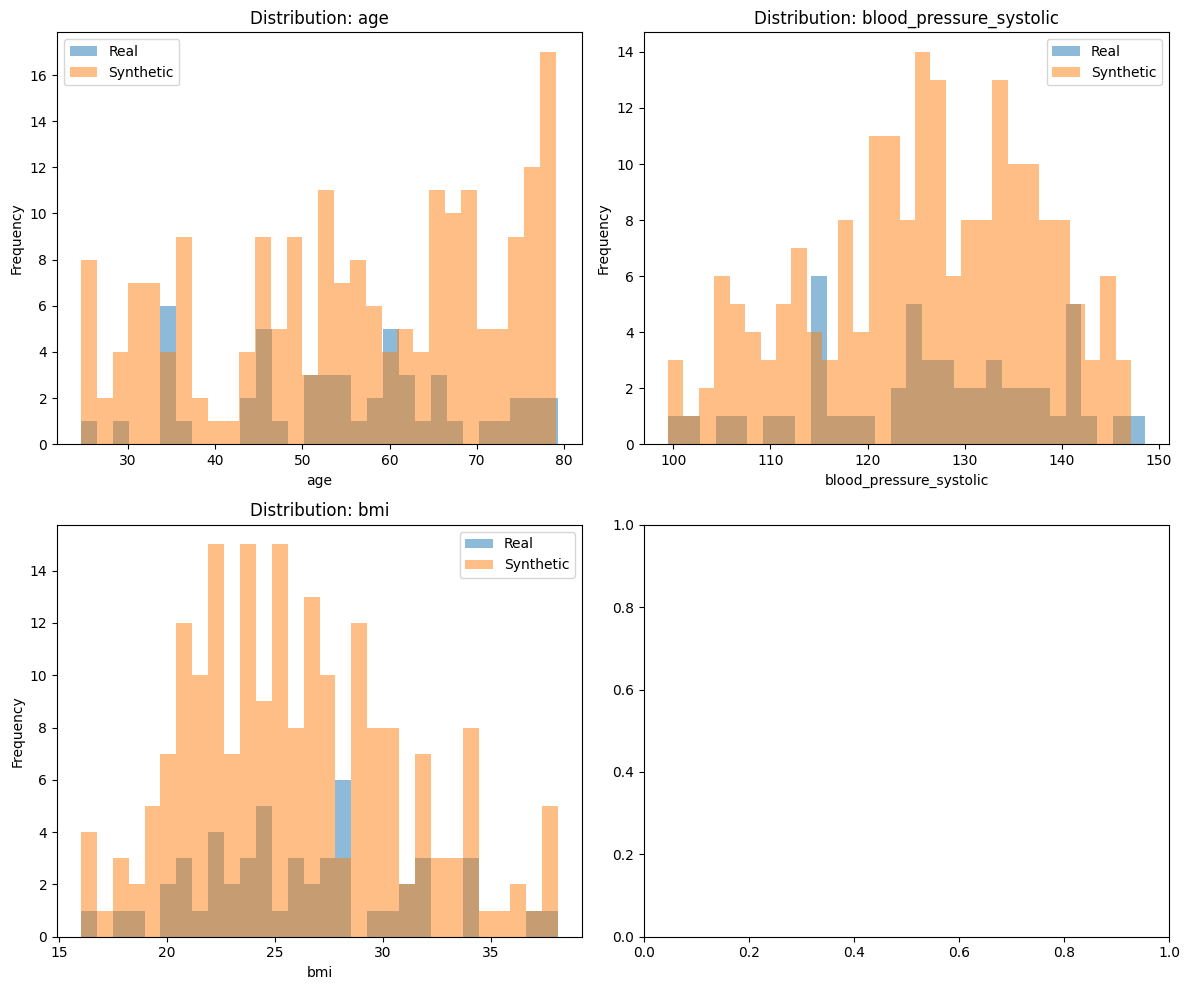

In [12]:
# Validate the synthetic data
print("Validating synthetic data quality...\n")

validation_results = pipeline.validator.validate_statistical_similarity(
    sample_df, sdv_synthetic
)

print("Statistical Similarity Results:")
print("=" * 50)
for column, metrics in validation_results.items():
    print(f"\n{column}:")
    print(f"  Similar distribution: {metrics['similar']}")
    print(f"  KS statistic: {metrics['ks_statistic']:.4f}")
    print(f"  p-value: {metrics['p_value']:.4f}")
    print(f"  Real mean: {metrics['real_mean']:.2f}, Synthetic mean: {metrics['synthetic_mean']:.2f}")
    print(f"  Real std: {metrics['real_std']:.2f}, Synthetic std: {metrics['synthetic_std']:.2f}")

privacy_check = pipeline.validator.check_privacy(sample_df, sdv_synthetic)
print("\n" + "=" * 50)
print("\nPrivacy Validation Results:")
print(f"  Mean minimum distance to real records: {privacy_check['mean_min_distance']:.4f}")
print(f"  Privacy risk level: {privacy_check['privacy_risk']}")

# Visualize the comparison
print("\nGenerating comparison visualizations...")
pipeline.validator.visualize_comparison(
    sample_df, sdv_synthetic, 
    columns=['age', 'blood_pressure_systolic', 'bmi']
)

In [16]:
class MultiModalGenerator:
    """
    Generate synthetic data across multiple modalities.
    """
    def __init__(self, llm, seed: int = 42):
        self.llm = llm
        self.faker = Faker()
        Faker.seed(seed)
        self.rng = np.random.RandomState(seed)
        self.llm_generator = LLMDataGenerator(llm)
    
    def generate_temporal_data(self, num_records: int, 
                              start_date: datetime, 
                              end_date: datetime) -> List[datetime]:
        """
        Generate synthetic timestamp data.
        
        Args:
            num_records (int): Number of timestamps to generate
            start_date (datetime): Start of date range
            end_date (datetime): End of date range
            
        Returns:
            List[datetime]: List of generated timestamps
        """
        # Calculate time delta
        time_delta = (end_date - start_date).total_seconds()
        
        # Generate random offsets
        offsets = self.rng.uniform(0, time_delta, num_records)
        
        # Create timestamps
        timestamps = [start_date + timedelta(seconds=offset) for offset in offsets]
        
        # Sort and return
        return sorted(timestamps)
    
    def generate_multimodal_dataset(self, schema: Dict[str, Any], 
                                   num_records: int) -> pd.DataFrame:
        """
        Generate a complete multi-modal synthetic dataset.
        
        Args:
            schema (Dict[str, Any]): Schema defining all modalities
            num_records (int): Number of records to generate
            
        Returns:
            pd.DataFrame: Multi-modal synthetic dataset
        """
        data = {}
        
        for field, config in schema.items():
            modality = config.get('modality', 'numerical')
            
            if modality == 'numerical':
                dist = config.get('distribution', 'normal')
                params = config.get('params', {})
                sampler = StatisticalSampler()
                data[field] = sampler.sample_numerical(dist, num_records, **params)
            
            elif modality == 'categorical':
                categories = config.get('categories', [])
                probs = config.get('probabilities', None)
                data[field] = self.rng.choice(categories, num_records, p=probs)
            
            elif modality == 'text':
                description = config.get('description', '')
                text_samples = self.llm_generator.generate_text_field(description, num_records)
                data[field] = text_samples if len(text_samples) == num_records else [''] * num_records
            
            elif modality == 'temporal':z
                start = config.get('start_date', datetime.now() - timedelta(days=365))
                end = config.get('end_date', datetime.now())
                data[field] = self.generate_temporal_data(num_records, start, end)
        
        return pd.DataFrame(data)

IndentationError: unexpected indent (2607981760.py, line 72)

<details>
    <summary>Click here for Solution</summary>

```python
class MultiModalGenerator:
    """
    Generate synthetic data across multiple modalities.
    """
    def __init__(self, llm, seed: int = 42):
        self.llm = llm
        self.faker = Faker()
        Faker.seed(seed)
        self.rng = np.random.RandomState(seed)
        self.llm_generator = LLMDataGenerator(llm)
    
    def generate_temporal_data(self, num_records: int, 
                              start_date: datetime, 
                              end_date: datetime) -> List[datetime]:
        """
        Generate synthetic timestamp data.
        
        Args:
            num_records (int): Number of timestamps to generate
            start_date (datetime): Start of date range
            end_date (datetime): End of date range
            
        Returns:
            List[datetime]: List of generated timestamps
        """
        # Calculate time delta
        time_delta = (end_date - start_date).total_seconds()
        
        # Generate random offsets
        offsets = self.rng.uniform(0, time_delta, num_records)
        
        # Create timestamps
        timestamps = [start_date + timedelta(seconds=offset) for offset in offsets]
        
        # Sort and return
        return sorted(timestamps)
    
    def generate_multimodal_dataset(self, schema: Dict[str, Any], 
                                   num_records: int) -> pd.DataFrame:
        """
        Generate a complete multi-modal synthetic dataset.
        
        Args:
            schema (Dict[str, Any]): Schema defining all modalities
            num_records (int): Number of records to generate
            
        Returns:
            pd.DataFrame: Multi-modal synthetic dataset
        """
        data = {}
        
        for field, config in schema.items():
            modality = config.get('modality', 'numerical')
            
            if modality == 'numerical':
                dist = config.get('distribution', 'normal')
                params = config.get('params', {})
                sampler = StatisticalSampler()
                data[field] = sampler.sample_numerical(dist, num_records, **params)
            
            elif modality == 'categorical':
                categories = config.get('categories', [])
                probs = config.get('probabilities', None)
                data[field] = self.rng.choice(categories, num_records, p=probs)
            
            elif modality == 'text':
                description = config.get('description', '')
                text_samples = self.llm_generator.generate_text_field(description, num_records)
                data[field] = text_samples if len(text_samples) == num_records else [''] * num_records
            
            elif modality == 'temporal':z
                start = config.get('start_date', datetime.now() - timedelta(days=365))
                end = config.get('end_date', datetime.now())
                data[field] = self.generate_temporal_data(num_records, start, end)
        
        return pd.DataFrame(data)
```

</details>


### Exercise 2 - Privacy Validation Framework


In [17]:
class PrivacyValidator:
    """
    Comprehensive privacy validation for synthetic data.
    """
    @staticmethod
    def check_exact_matches(real_data: pd.DataFrame, 
                           synthetic_data: pd.DataFrame,
                           columns: Optional[List[str]] = None) -> Dict[str, Any]:
        """
        Check for exact matches between real and synthetic records.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset
            columns (Optional[List[str]]): Specific columns to check
            
        Returns:
            Dict[str, Any]: Match statistics and privacy assessment
        """
        if columns is None:
            columns = real_data.columns.tolist()
        
        # Create string representations of records
        real_records = real_data[columns].apply(
            lambda row: '|'.join(row.astype(str)), axis=1
        )
        synthetic_records = synthetic_data[columns].apply(
            lambda row: '|'.join(row.astype(str)), axis=1
        )
        
        # Find exact matches
        matches = set(real_records) & set(synthetic_records)
        
        num_matches = len(matches)
        match_percentage = (num_matches / len(synthetic_data)) * 100
        
        return {
            'exact_matches': num_matches,
            'match_percentage': match_percentage,
            'privacy_risk': 'HIGH' if num_matches > 0 else 'LOW',
            'recommendation': 'REJECT: Contains exact matches' if num_matches > 0 
                            else 'ACCEPT: No exact matches found'
        }
    
    @staticmethod
    def check_quasi_identifiers(real_data: pd.DataFrame,
                               synthetic_data: pd.DataFrame,
                               quasi_id_columns: List[str]) -> Dict[str, Any]:
        """
        Check if quasi-identifier combinations appear in both datasets.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset
            quasi_id_columns (List[str]): Columns that form quasi-identifiers
            
        Returns:
            Dict[str, Any]: Quasi-identifier overlap statistics
        """
        # Group by quasi-identifiers
        real_groups = real_data.groupby(quasi_id_columns).size()
        synthetic_groups = synthetic_data.groupby(quasi_id_columns).size()
        
        # Find overlapping combinations
        overlap = set(real_groups.index) & set(synthetic_groups.index)
        
        # Calculate k-anonymity
        k_anonymity_real = real_groups.min() if len(real_groups) > 0 else 0
        k_anonymity_synthetic = synthetic_groups.min() if len(synthetic_groups) > 0 else 0
        
        overlap_percentage = (len(overlap) / len(synthetic_groups)) * 100 if len(synthetic_groups) > 0 else 0
        
        return {
            'overlapping_combinations': len(overlap),
            'overlap_percentage': overlap_percentage,
            'k_anonymity_real': k_anonymity_real,
            'k_anonymity_synthetic': k_anonymity_synthetic,
            'privacy_risk': 'HIGH' if overlap_percentage > 50 else 
                          'MEDIUM' if overlap_percentage > 20 else 'LOW',
            'recommendation': f'k-anonymity: {k_anonymity_synthetic} - ' + 
                            ('GOOD (≥5)' if k_anonymity_synthetic >= 5 else 'POOR (<5)')
        }

<details>
    <summary>Click here for Solution</summary>

```python
class PrivacyValidator:
    """
    Comprehensive privacy validation for synthetic data.
    """
    @staticmethod
    def check_exact_matches(real_data: pd.DataFrame, 
                           synthetic_data: pd.DataFrame,
                           columns: Optional[List[str]] = None) -> Dict[str, Any]:
        """
        Check for exact matches between real and synthetic records.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset
            columns (Optional[List[str]]): Specific columns to check
            
        Returns:
            Dict[str, Any]: Match statistics and privacy assessment
        """
        if columns is None:
            columns = real_data.columns.tolist()
        
        # Create string representations of records
        real_records = real_data[columns].apply(
            lambda row: '|'.join(row.astype(str)), axis=1
        )
        synthetic_records = synthetic_data[columns].apply(
            lambda row: '|'.join(row.astype(str)), axis=1
        )
        
        # Find exact matches
        matches = set(real_records) & set(synthetic_records)
        
        num_matches = len(matches)
        match_percentage = (num_matches / len(synthetic_data)) * 100
        
        return {
            'exact_matches': num_matches,
            'match_percentage': match_percentage,
            'privacy_risk': 'HIGH' if num_matches > 0 else 'LOW',
            'recommendation': 'REJECT: Contains exact matches' if num_matches > 0 
                            else 'ACCEPT: No exact matches found'
        }
    
    @staticmethod
    def check_quasi_identifiers(real_data: pd.DataFrame,
                               synthetic_data: pd.DataFrame,
                               quasi_id_columns: List[str]) -> Dict[str, Any]:
        """
        Check if quasi-identifier combinations appear in both datasets.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset
            quasi_id_columns (List[str]): Columns that form quasi-identifiers
            
        Returns:
            Dict[str, Any]: Quasi-identifier overlap statistics
        """
        # Group by quasi-identifiers
        real_groups = real_data.groupby(quasi_id_columns).size()
        synthetic_groups = synthetic_data.groupby(quasi_id_columns).size()
        
        # Find overlapping combinations
        overlap = set(real_groups.index) & set(synthetic_groups.index)
        
        # Calculate k-anonymity
        k_anonymity_real = real_groups.min() if len(real_groups) > 0 else 0
        k_anonymity_synthetic = synthetic_groups.min() if len(synthetic_groups) > 0 else 0
        
        overlap_percentage = (len(overlap) / len(synthetic_groups)) * 100 if len(synthetic_groups) > 0 else 0
        
        return {
            'overlapping_combinations': len(overlap),
            'overlap_percentage': overlap_percentage,
            'k_anonymity_real': k_anonymity_real,
            'k_anonymity_synthetic': k_anonymity_synthetic,
            'privacy_risk': 'HIGH' if overlap_percentage > 50 else 
                          'MEDIUM' if overlap_percentage > 20 else 'LOW',
            'recommendation': f'k-anonymity: {k_anonymity_synthetic} - ' + 
                            ('GOOD (≥5)' if k_anonymity_synthetic >= 5 else 'POOR (<5)')
        }
```

</details>
